该Notebook用于数据预处理。
# 数据集信息查看

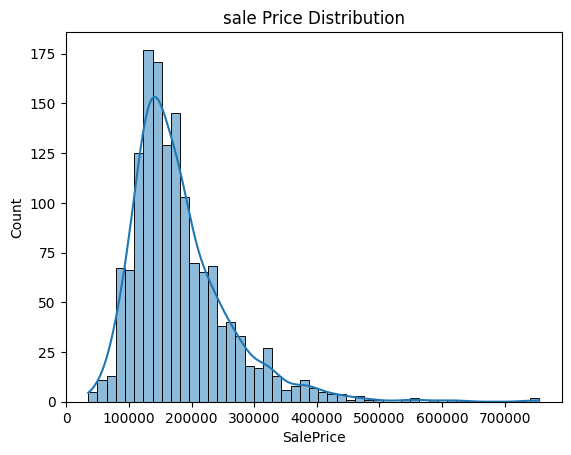

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("input/train.csv", sep=",", header=0, na_values=["NA", "NaN", " "]) # 读取CSV文件，指定缺失值标识
train = df.drop("Id", axis=1) # 删除Id列，因为它对预测没有意义
test = pd.read_csv("input/test.csv", sep=",", header=0, na_values=["NA", "NaN", " "]) # 读取测试数据
sns.histplot(train["SalePrice"], kde=True) # histplot(data, kde=True)，作用是绘制数据的直方图并叠加核密度估计曲线
plt.title("sale Price Distribution")
plt.show()

# .describe() 方法用于生成描述性统计信息的汇总，包括计数、均值、标准差、最小值、四分位数和最大值等。.T 属性用于转置 DataFrame，使行和列互换。
train.describe().T

SalePrice 分布是右偏的，这意味着许多低价房屋，少数非常昂贵（异常值）。

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


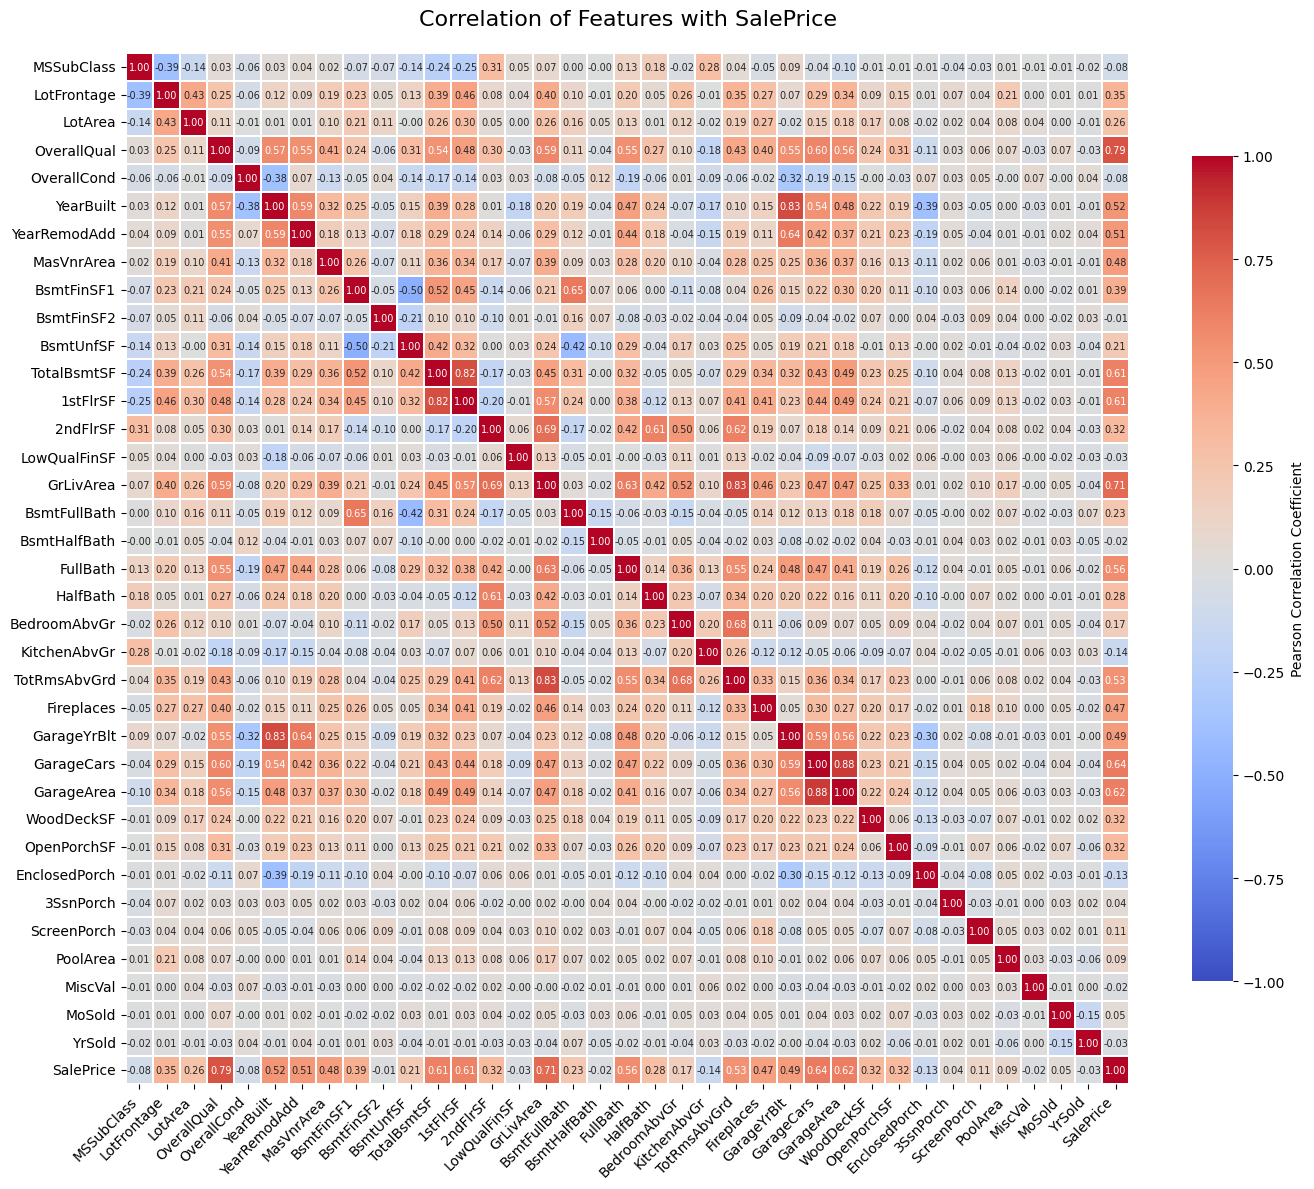

In [2]:
# 筛选与 SalePrice 相关的特征
'''
.corr() 方法用于计算 DataFrame 中各列之间的相关系数矩阵。参数 numeric_only=True 表示只计算数值型列之间的相关性； min_periods=10 表示在计算相关系数时，至少需要有 10 个非缺失值的数据点。
["SalePrice"] 用于选择相关系数矩阵中与 "SalePrice" 列相关的那一列。
.sort_values(ascending=False) 则是将这些相关系数按降序排列，以便找出与 "SalePrice" 相关性最高的特征。 
'''
corr = train.corr(method="pearson", numeric_only=True, min_periods=10)["SalePrice"].sort_values(ascending=False)
print(corr.head(10)) # 输出与 SalePrice 相关性最高的前10个特征

# 可视化相关矩阵
corr_matrix = train.corr(method="pearson", numeric_only=True, min_periods=10)

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    annot=True,          
    annot_kws={'size': 7}, 
    fmt='.2f',
    cmap="coolwarm",   
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation Coefficient'}, 
    vmin=-1, vmax=1,
    linewidths=0.1
)

plt.title("Correlation of Features with SalePrice", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


总体而言，Qual（房屋质量）和 GrLivArea（建筑物离地面的面积）与价格具有很高的相关性。

# 缺失值处理

In [3]:
# --- 插补前检查缺失值 ---
'''
.isnull() 方法返回一个布尔型DataFrame，表示每个元素是否为缺失值（True表示缺失，False表示非缺失）；sum() 方法对布尔值进行求和，得到每列缺失值的数量；mean() 方法计算每列缺失值的比例（即缺失数量除以总行数），乘以100转换为百分比. 这两个方法得到的都是series对象，其索引完全一致（都是列名）。使用pd.DataFrame({})将它们组合成一个新的DataFrame，并指定列名为 '缺失数量' 和 '缺失比例'，索引自动合并。最后，使用sort_values() 方法按照 '缺失比例' 列进行降序排序，以便查看缺失值比例最高的特征。
'''
missing_info = pd.DataFrame({
    '缺失数量': train.isnull().sum(), 
    '缺失比例': train.isnull().mean() * 100
}).sort_values('缺失比例', ascending=False)

print(missing_info.head(10))
train = train.drop(columns=['PoolQC']) # 删除PoolQC列，因为缺失比例过高
test = test.drop(columns=['PoolQC']) # 同样删除测试数据中的PoolQC列

# --- 简单插补（填充缺失值） ---
# 筛选数值型特征列（int64整数型、float64浮点型）
num_cols = train.drop(columns=['SalePrice']).select_dtypes(include=["int64", "float64"]).columns

# 筛选分类型特征列（object字符串型）
cat_cols = train.select_dtypes(include=["object"]).columns

# 输出数值型特征的数量和分类型特征的数量
print(f"数值型特征数量：{len(num_cols)}")
print(f"分类型特征数量：{len(cat_cols)}")

# 数值型特征：用中位数填充缺失值（抗异常值干扰）
for col in num_cols:
    med = train[col].median()
    train[col] = train[col].fillna(med)
    test[col] = test[col].fillna(med) # 同样对测试数据进行中位数填充。注意这里使用 train[col].median() 来填充 test 数据中的缺失值，以保持训练和测试数据的一致性。
# 分类型特征：用众数填充缺失值（取出现频率最高的类别）
for col in cat_cols:
    mode = train[col].mode()[0] # 计算众数
    train[col] = train[col].fillna(mode) # .mode() 方法返回一个 Series，表示每个元素出现的频率。 [0] 用于取出频率最高的类别。
    test[col] = test[col].fillna(mode) # 同样对测试数据进行众数填充
    

              缺失数量       缺失比例
PoolQC        1453  99.520548
MiscFeature   1406  96.301370
Alley         1369  93.767123
Fence         1179  80.753425
MasVnrType     872  59.726027
FireplaceQu    690  47.260274
LotFrontage    259  17.739726
GarageQual      81   5.547945
GarageType      81   5.547945
GarageFinish    81   5.547945
数值型特征数量：36
分类型特征数量：42


#  类别编码

In [4]:
train.columns = train.columns.str.strip().str.lower() #去除空格，转为小写
test.columns = test.columns.str.strip().str.lower() #同样处理测试数据的列名
train["mszoning"] = train["mszoning"].str.upper() #该列元素转为大写
test["mszoning"] = test["mszoning"].str.upper() #同样处理测试数据的 mszoning 列
num_cols = num_cols.str.strip().str.lower() #去除空格，转为小写
cat_cols = cat_cols.str.strip().str.lower() #同样处理特征列名

In [5]:
# 定义需要进行「标签编码」的有序分类特征列
# 这些列的文本值存在明确优先级（如质量：好>中>差），适合用连续数字表示顺序
ordinal_cols = ["exterqual", "extercond", "heatingqc", "kitchenqual"]
# 列名含义：
# exterqual: 外部材料质量 | extercond: 外部状况 | heatingqc: 供暖质量 | kitchenqual: 厨房质量

# --- 编码前查看数据 ---
print("\n 标签编码前的唯一值（以KitchenQual为例）:")
# 查看kitchenqual列的各文本值及其出现次数，确认编码前的原始分布
print(train["kitchenqual"].value_counts())

# 初始化标签编码器（将文本类别映射为0、1、2...等连续整数）
encoder = LabelEncoder()

# 对所有有序分类列逐一进行标签编码
for col in ordinal_cols:
    # astype(str): 将列转换为字符串类型，以便LabelEncoder()可以处理
    # encoder.fit_transform(): 先学习列中所有唯一文本值，再将其转换为对应的整数编码
    train[col] = encoder.fit_transform(train[col].astype(str))
    test[col] = encoder.transform(test[col].astype(str)) # 同样对测试数据进行标签编码，使用相同的编码器保持一致

# --- 编码后查看结果 ---
print("\n 标签编码后的唯一值（以KitchenQual为例）:")
# 查看编码后的整数分布，验证文本是否成功转为数字
print(train["kitchenqual"].value_counts())

# --- 对名义特征进行one-hot编码 ---
# 定义需要进行「one-hot编码」的名义分类特征列
# 这些列的文本值无明确顺序（仅为不同类别，如小区、房屋样式），不适合用连续数字表示
nominal_cols = [col for col in cat_cols if col not in ordinal_cols]
# 执行one-hot编码：
# pd.get_dummies(): 将每个名义列拆分为多个二进制列（某类别存在则为1，否则为0）
# columns=nominal_cols: 指定要编码的列
# drop_first=True: 去掉每个特征的第一个类别列（避免多重共线性，不影响模型训练）
print("\none-hot编码前训练集的总列数:", train.shape[1])
print("one-hot编码前测试集的总列数:", test.shape[1]) 
train_2 = pd.get_dummies(train, columns=nominal_cols, drop_first=True)
print("\none-hot编码后训练集的总列数:", train.shape[1]) # 输出编码后的数据列数，验证one-hot编码是否新增了列
test_2 = pd.get_dummies(test, columns=nominal_cols, drop_first=True)
print("one-hot编码后测试集的总列数:", test.shape[1]) # 输出编码后的数据列数，验证one-hot编码是否新增了列


 标签编码前的唯一值（以KitchenQual为例）:
kitchenqual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

 标签编码后的唯一值（以KitchenQual为例）:
kitchenqual
3    735
2    586
0    100
1     39
Name: count, dtype: int64

one-hot编码前训练集的总列数: 79
one-hot编码前测试集的总列数: 79

one-hot编码后训练集的总列数: 79
one-hot编码后测试集的总列数: 79


训练集和测试集在编码后列数不一致，可能是因为某些类别在训练集中存在但在测试集中不存在，或者反之亦然。我们需要确保训练集和测试集具有相同的列，以便模型能够正确处理它们。因此，我们这里先不进行独热编码，转而在后续步骤中使用ColumnTransformer来同时处理数值特征和类别特征，这样可以确保训练集和测试集的列数一致。

# 非正态分布数据的处理

我们数据集中的特征往往具有右偏分布（如SalePrice、GrLivArea等），这会影响某些模型的性能。我们可以通过对这些特征进行对数变换来使其更接近正态分布，从而提高模型的表现。

In [6]:
train['saleprice'] = np.log1p(train['saleprice'])

除了目标值SalePrice，我们还需要查看有哪些数值特征具有右偏分布。我们可以计算数值特征的偏度（skewness）来识别这些特征。偏度大于0表示右偏分布，偏度越大，分布越偏斜。我们可以设置一个阈值（如0.5）来筛选出需要进行对数变换的特征。

In [7]:
# 对数值型特征计算偏度并降序排列
train_skew = train[num_cols].skew().sort_values(ascending=False)
print("\n数值型特征的偏度（降序排列）:")
print(train_skew)


数值型特征的偏度（降序排列）:
miscval          24.476794
poolarea         14.828374
lotarea          12.207688
3ssnporch        10.304342
lowqualfinsf      9.011341
kitchenabvgr      4.488397
bsmtfinsf2        4.255261
screenporch       4.122214
bsmthalfbath      4.103403
enclosedporch     3.089872
masvnrarea        2.677616
lotfrontage       2.409147
openporchsf       2.364342
bsmtfinsf1        1.685503
wooddecksf        1.541376
totalbsmtsf       1.524255
mssubclass        1.407657
1stflrsf          1.376757
grlivarea         1.366560
bsmtunfsf         0.920268
2ndflrsf          0.813030
overallcond       0.693067
totrmsabvgrd      0.676341
halfbath          0.675897
fireplaces        0.649565
bsmtfullbath      0.596067
overallqual       0.216944
mosold            0.212053
bedroomabvgr      0.211790
garagearea        0.179981
yrsold            0.096269
fullbath          0.036562
garagecars       -0.342549
yearremodadd     -0.503562
yearbuilt        -0.613461
garageyrblt      -0.678333
dtype: floa

我们将偏度大于0.7的数值特征进行对数变换（加1以避免对0取对数），以使它们更接近正态分布。log1p函数的数学定义是$ y = \log_{\mathrm e}(1 + x)$，逆变换是$ x = \mathrm e^y - 1.$

In [8]:
for col in train_skew[train_skew > 0.7].index: # 筛选偏度大于0.6的特征列
    train[col] = np.log1p(train[col]) # 对这些特征进行对数变换（加1以避免对0取对数）
    test[col] = np.log1p(test[col]) # 同样对测试数据中的这些特征进行对数变换

# 将 saleprice 移到最后一列
saleprice = train.pop('saleprice') # pop() 方法用于从 DataFrame 中删除指定列（这里是 'saleprice' 列），并返回该列的内容。这样做的目的是将 'saleprice' 列移到 DataFrame 的最后一列位置。
train['saleprice'] = saleprice # 将 'saleprice' 列添加回 DataFrame 的最后一列位置

print(f'训练集形状: {train.shape}, 测试集形状: {test.shape}')

# 把处理后的dataframe输出到house_price_prediction_processed.csv
train.to_csv('input/train_processed.csv', index=False)
test.to_csv('input/test_processed.csv', index=False)

train_demo = train.head(20)
test_demo = test.head(5)
train_demo.to_csv('input/train_demo.csv', index=False)
test_demo.to_csv('input/test_demo.csv', index=False)

训练集形状: (1460, 79), 测试集形状: (1459, 79)
